# Bible Grammar Statistics

A full statistics showcase covering Hebrew OT stems and Greek NT morphology.

Export this notebook as HTML: `jupyter nbconvert --to html 03_statistics.ipynb`

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from bible_grammar.query import query, reload
from bible_grammar import stats, charts
reload()
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Hebrew Verb Stem Totals (entire OT)

In [2]:
all_stems = stats.freq_table(query(source='TAHOT', part_of_speech='Verb'), 'stem')
all_stems

,stem,count
0,Qal,43296
1,Hiphil,6964
2,Piel,4953
3,,4036
4,Niphal,3711
5,Hithpael,880
6,Pual,458
7,Hophal,379
8,Haphel,126
9,Q,55


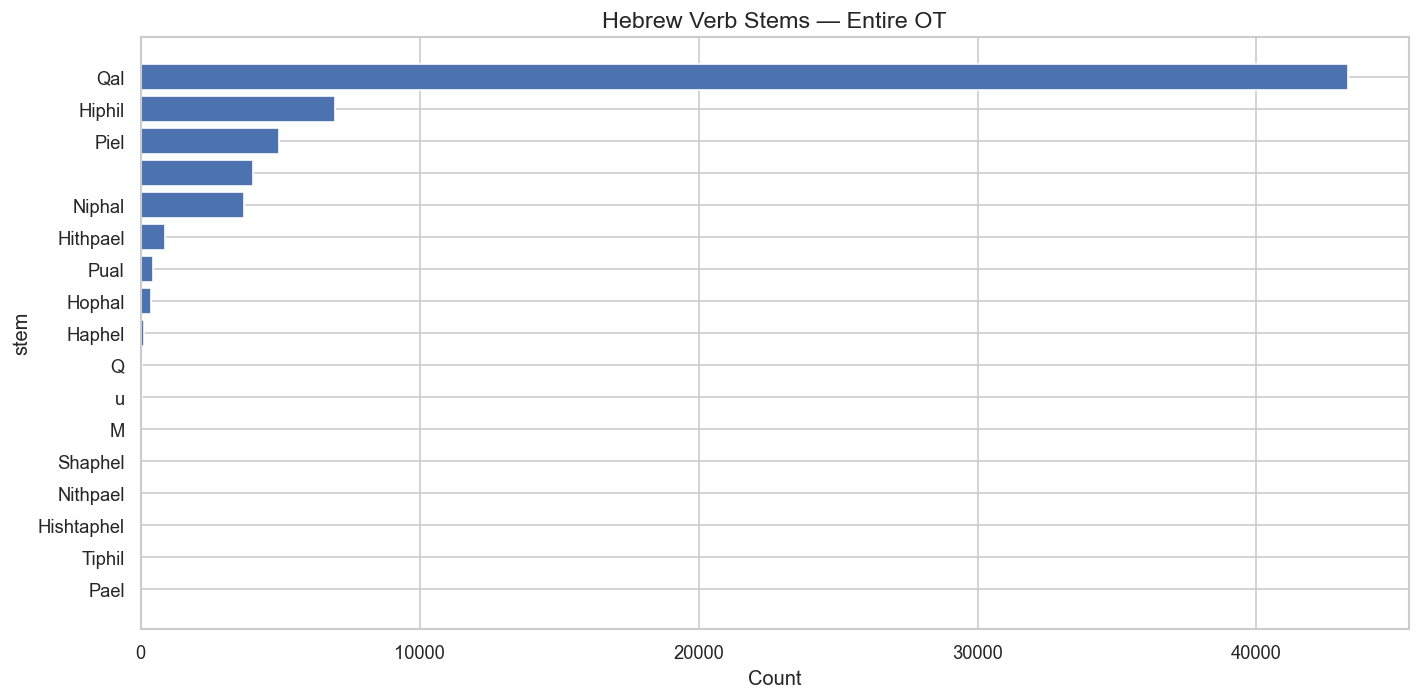

In [3]:
fig = charts.bar_chart(all_stems, x='stem', title='Hebrew Verb Stems — Entire OT',
                       output_path='../output/charts/ot_verb_stems_total.png')
plt.show()

## 2. Verb Stem Distribution Across Torah Books

In [4]:
torah_stems = stats.freq_table(
    query(book_group='torah', part_of_speech='Verb'), ['book_id', 'stem']
)
# Keep top 6 stems for readability
top_stems = torah_stems.groupby('stem')['count'].sum().nlargest(6).index
torah_top = torah_stems[torah_stems['stem'].isin(top_stems)]
torah_top.head(20)

,book_id,stem,count
0,Gen,Qal,3530
1,Exo,Qal,2296
2,Deu,Qal,2011
3,Num,Qal,2009
4,Lev,Qal,1374
5,Gen,Hiphil,395
6,Exo,Piel,347
7,Lev,Hiphil,336
8,Gen,,334
9,Lev,Piel,306


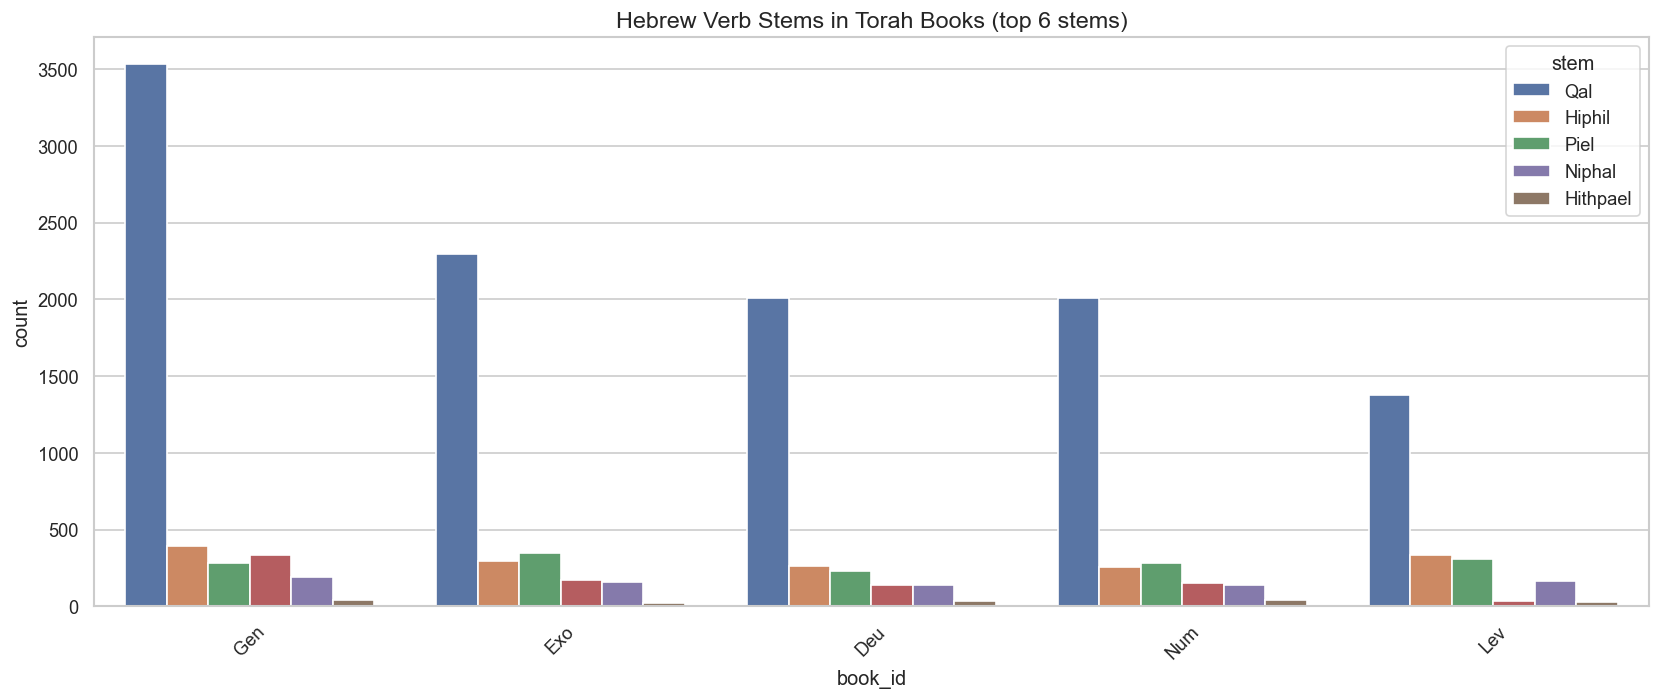

In [5]:
fig = charts.grouped_bar(
    torah_top, x='book_id', hue='stem',
    title='Hebrew Verb Stems in Torah Books (top 6 stems)',
    output_path='../output/charts/torah_verb_stems_grouped.png'
)
plt.show()

## 3. Niphal Perfects by Book

Total: 2601


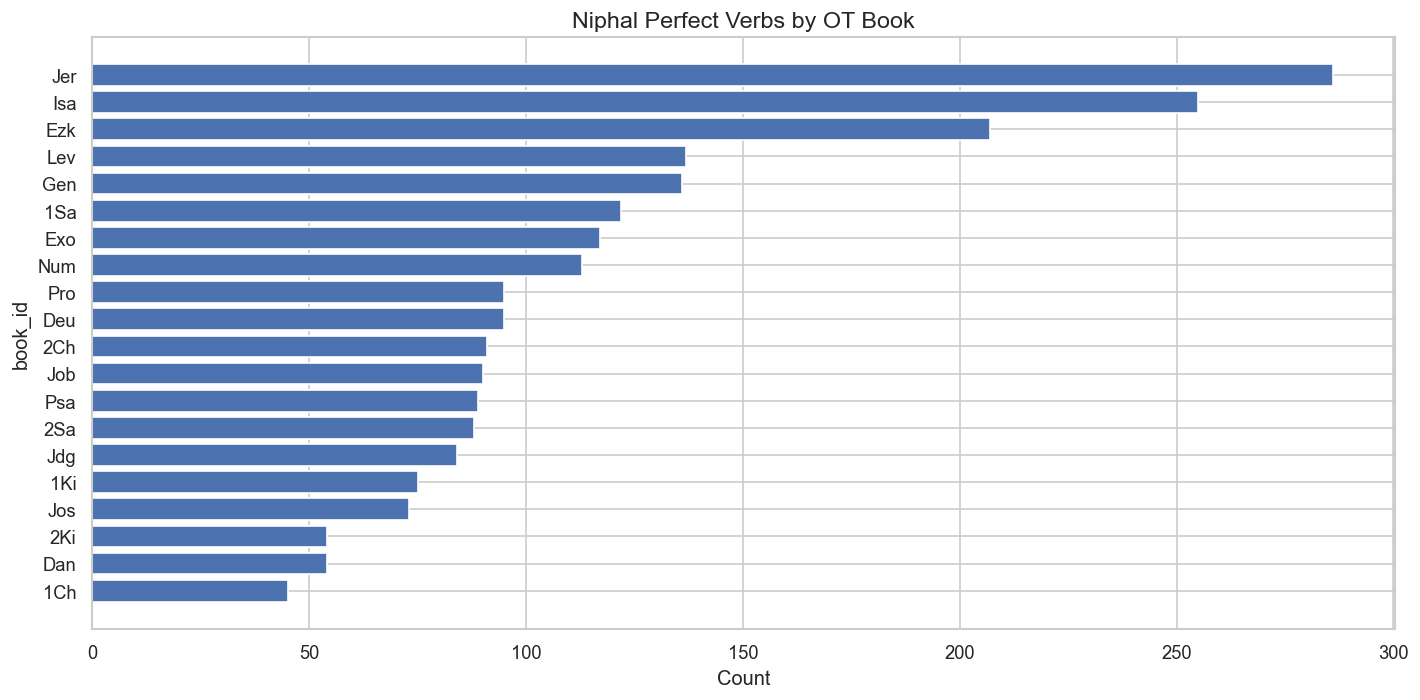

In [6]:
nip = stats.niphal_perfects_by_book()
print(f"Total: {nip['count'].sum()}")
fig = charts.bar_chart(nip, x='book_id',
                       title='Niphal Perfect Verbs by OT Book',
                       output_path='../output/charts/niphal_perfects.png')
plt.show()

## 4. Greek Tense × Voice in the NT

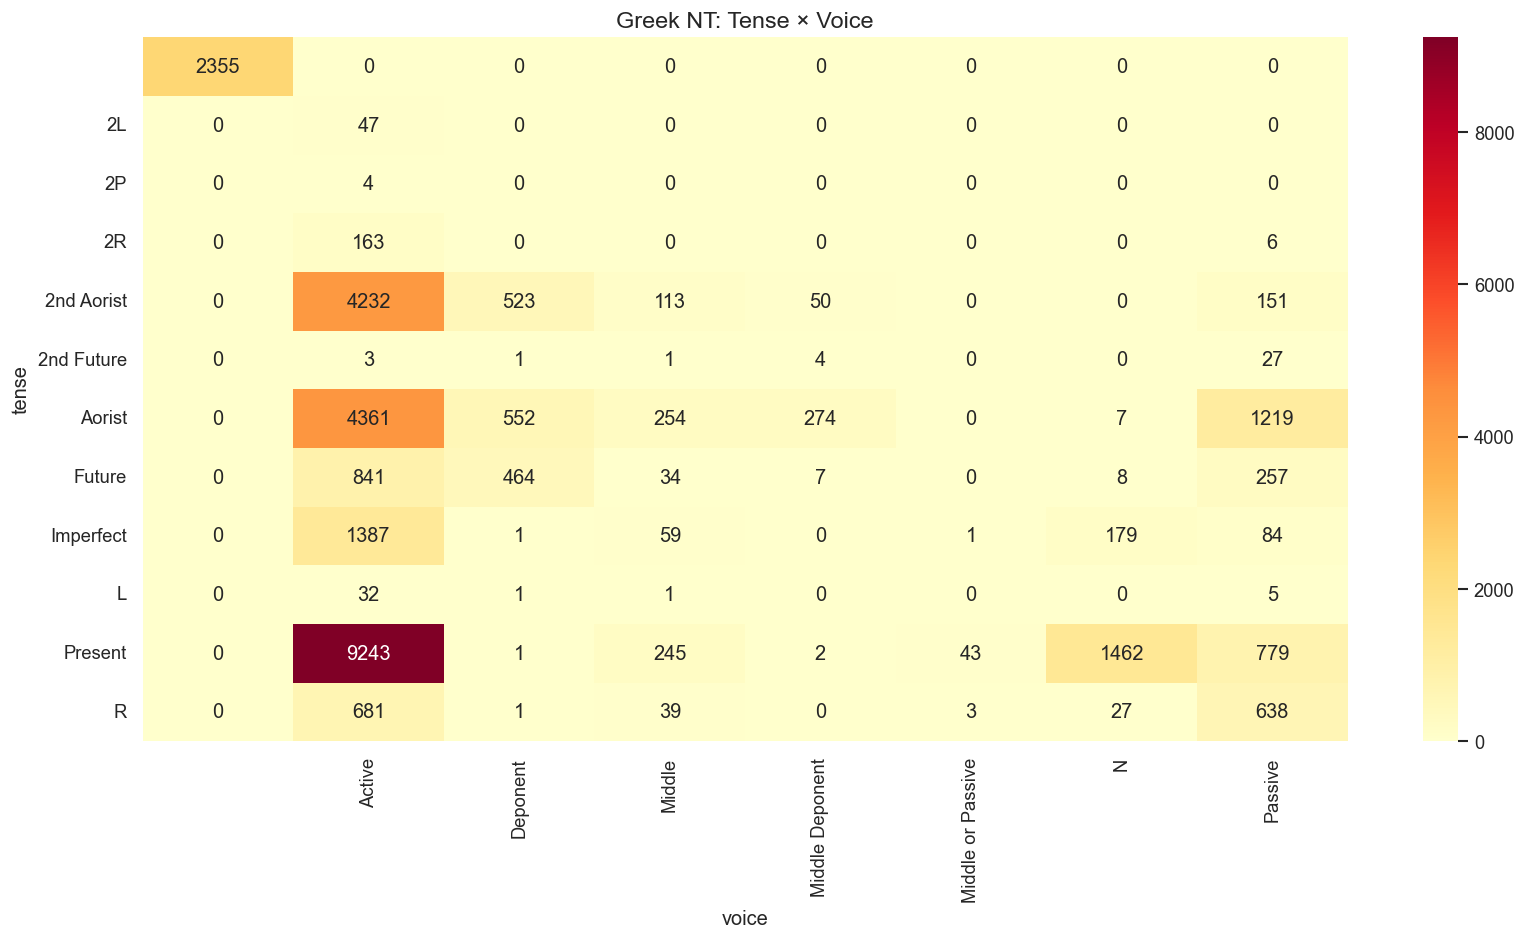

In [7]:
nt_verbs = stats.greek_verb_forms()
tv = nt_verbs.groupby(['tense','voice'])['count'].sum().reset_index()
fig = charts.heatmap(tv, index='tense', columns='voice',
                     title='Greek NT: Tense × Voice',
                     output_path='../output/charts/nt_tense_voice.png')
plt.show()

## 5. Greek Aorist Passives in Paul vs. Rest of NT

Aorist Passives — Paul: 340, Rest of NT: 1030


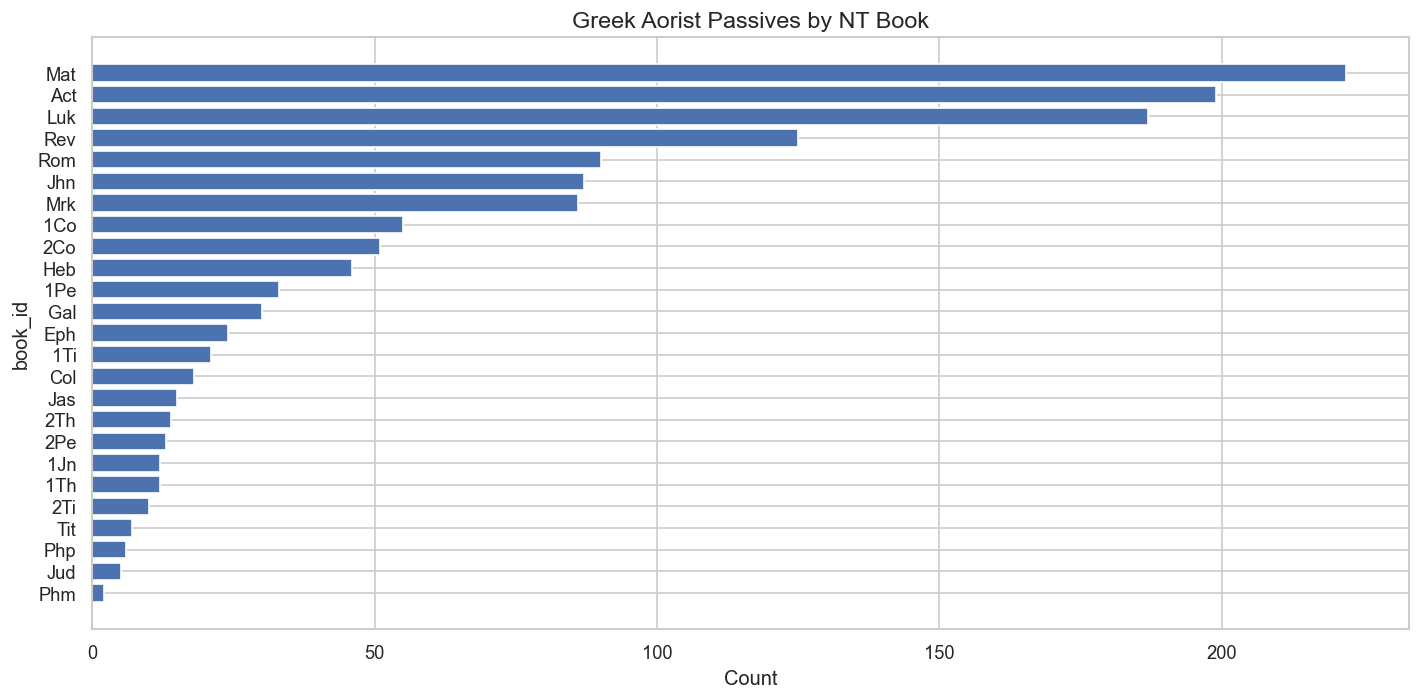

In [8]:
paul_ap = query(book_group='pauline', tense='Aorist', voice='Passive')
other_ap = query(testament='NT', tense='Aorist', voice='Passive')
other_ap = other_ap[~other_ap['book_id'].isin(paul_ap['book_id'].unique())]
print(f"Aorist Passives — Paul: {len(paul_ap)}, Rest of NT: {len(other_ap)}")

by_book = query(testament='NT', tense='Aorist', voice='Passive')
by_book_count = stats.freq_table(by_book, 'book_id')
fig = charts.bar_chart(by_book_count, x='book_id', top_n=None,
                       title='Greek Aorist Passives by NT Book',
                       output_path='../output/charts/nt_aorist_passive_by_book.png')
plt.show()

## 6. Export All Verb Data to CSV

In [9]:
heb_verbs = query(source='TAHOT', part_of_speech='Verb')
heb_verbs.to_csv('../output/exports/hebrew_verbs.csv', index=False)
print(f"Hebrew verbs exported: {len(heb_verbs):,} rows")

grk_verbs = query(source='TAGNT', part_of_speech='Verb')
grk_verbs.to_csv('../output/exports/greek_verbs.csv', index=False)
print(f"Greek verbs exported:  {len(grk_verbs):,} rows")

Hebrew verbs exported: 64,952 rows
Greek verbs exported:  30,872 rows
